## Ejercicio Time Series Forecast
Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolínea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

Para ello, se pide:
1. Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?
2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window con el valor de seasonality obtenido en el apartado anterior. Tienes que usar la función rolling() del DataFrame.
3. Comprueba de manera estadística si la serie es o no stationary.
4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary. Acuérdate después del forecast de invertir la transformación.
5. Divide en train y test. Guarda 20 muestras para test.
6. Crea tu primer modelo ARIMA. Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.
7. Representa en una gráfica los datos de test y tus predicciones.
8. Prueba un decission tree y un random forest, a ver qué rendimiento presentan.

In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga datos y representa la serie
Carga datos (AirPassengers.csv) y representa la serie. ¿Hay seasonality? ¿Cada cuanto?

In [123]:
df = pd.read_csv("data\AirPassengers.csv")
df.head()

,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [124]:
df.info() # no hay nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    144 non-null    object
 1   value   144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [125]:
df["date"] = pd.to_datetime(df["date"]) # paso date a datetime
df.set_index("date", inplace=True) # lo pongo como index para poder hacer fácilmente los ejercicios

In [126]:
df.head()

,value
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


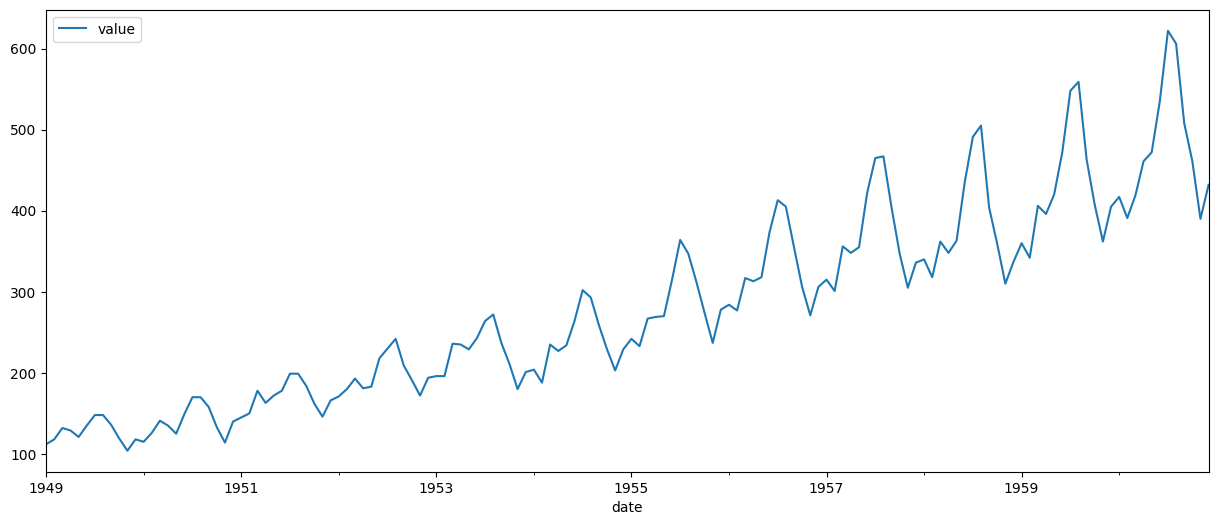

In [127]:
df.plot(figsize=(15,6));

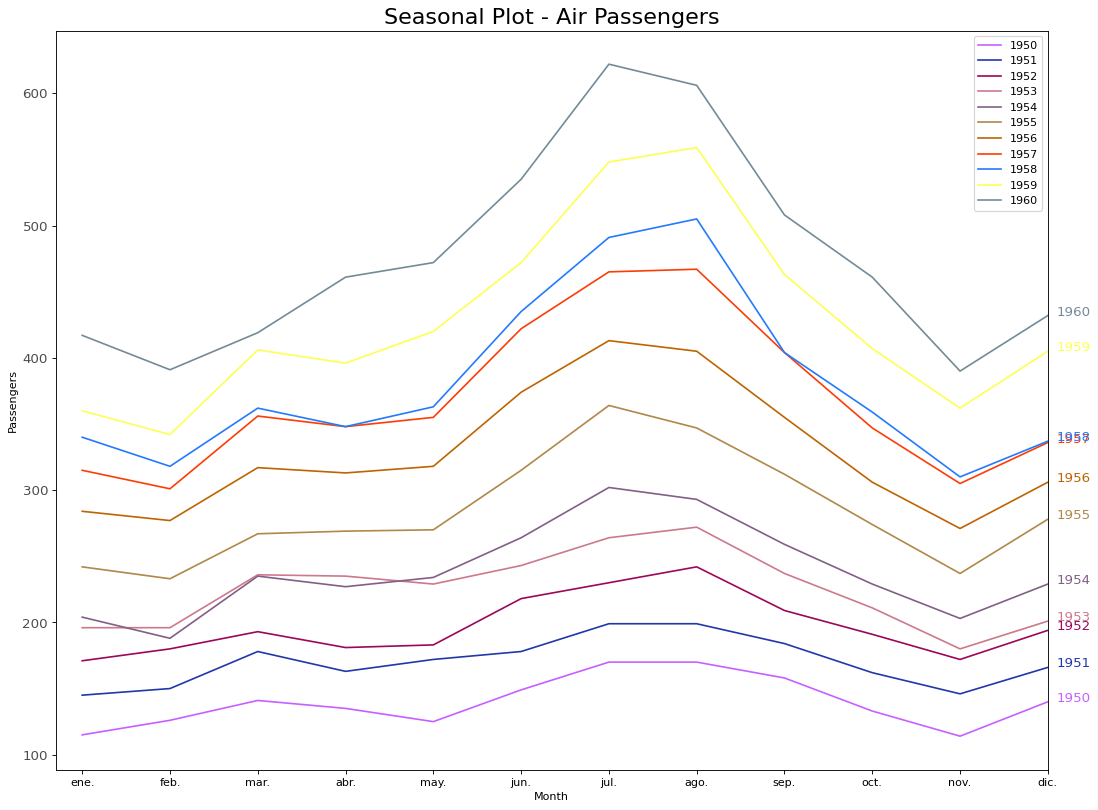

In [128]:
import numpy as np
import matplotlib as mpl

df.reset_index(inplace=True)

# Prepare data
df['year'] = [d.year for d in df.date]
df['month'] = [d.strftime('%b') for d in df.date]
years = df['year'].unique()

# Prep Colors
np.random.seed(100)
mycolors = np.random.choice(list(mpl.colors.XKCD_COLORS.keys()), len(years), replace=False)

# Draw Plot
plt.figure(figsize=(16, 12), dpi=80)
for i, y in enumerate(years):
    if i > 0:
        plt.plot('month', 'value', data=df.loc[df.year == y, :], color=mycolors[i], label=y)
        plt.text(df.loc[df.year == y, :].shape[0] - .9, df.loc[df.year == y, 'value'][-1:].values[0], y, fontsize=12, color=mycolors[i])

# Decoration
plt.gca().set(xlim=(-0.3, 11), ylabel='Passengers', xlabel='Month')
plt.yticks(fontsize=12, alpha=.7)
plt.title("Seasonal Plot - Air Passengers", fontsize=20)
plt.legend()
plt.show();

Los meses con más pasajeros son, sin duda, los meses de verano: junio, julio, agosto y septiembre. También se nota una ligera subida en diciembre.

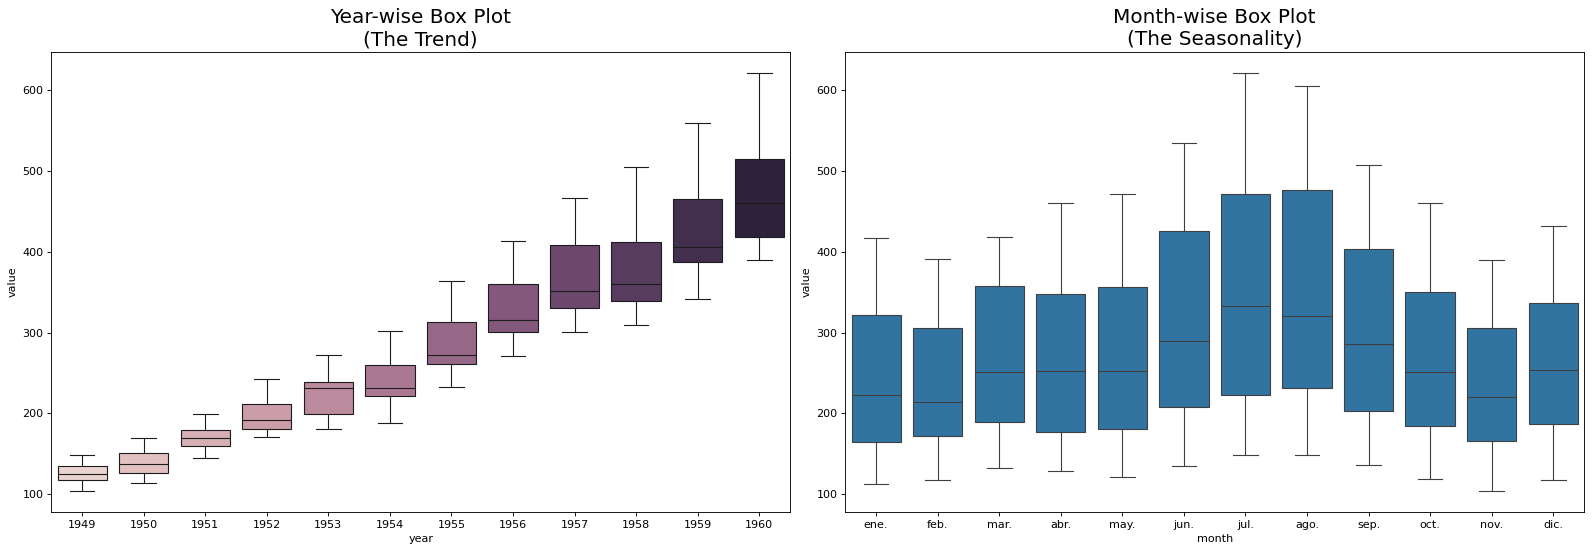

In [129]:
import seaborn as sns

# Draw Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 7), dpi=80)

sns.boxplot(x='year', y='value', data=df, ax=axes[0], hue='year', legend=False)
sns.boxplot(x='month', y='value', data=df, ax=axes[1])

# Set Title
axes[0].set_title('Year-wise Box Plot\n(The Trend)', fontsize=18)
axes[1].set_title('Month-wise Box Plot\n(The Seasonality)', fontsize=18)

plt.tight_layout()
plt.show();

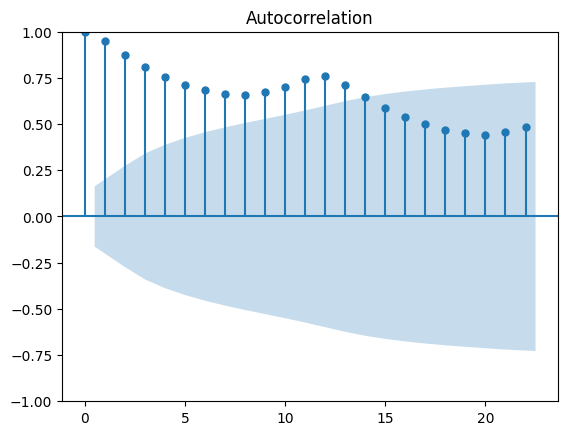

In [130]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df.value.values);

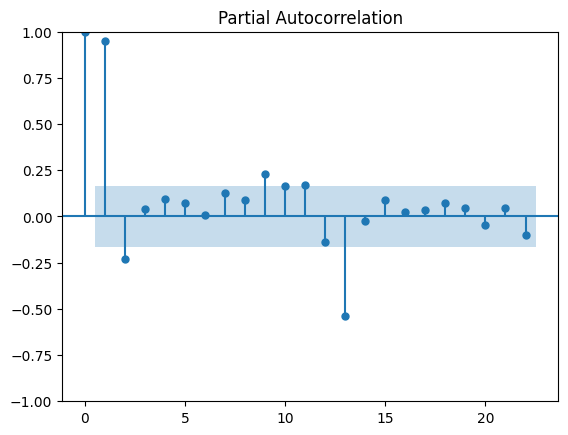

In [131]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df.value.values);

Hay estacionalidad cada 9-10-11 meses.

## 2. Crea en una gráfica la variable original + su media obtenida mediante una rolling window comparando el valor de seasonality obtenido en el apartado anterior.
Tienes que usar la función rolling() del DataFrame

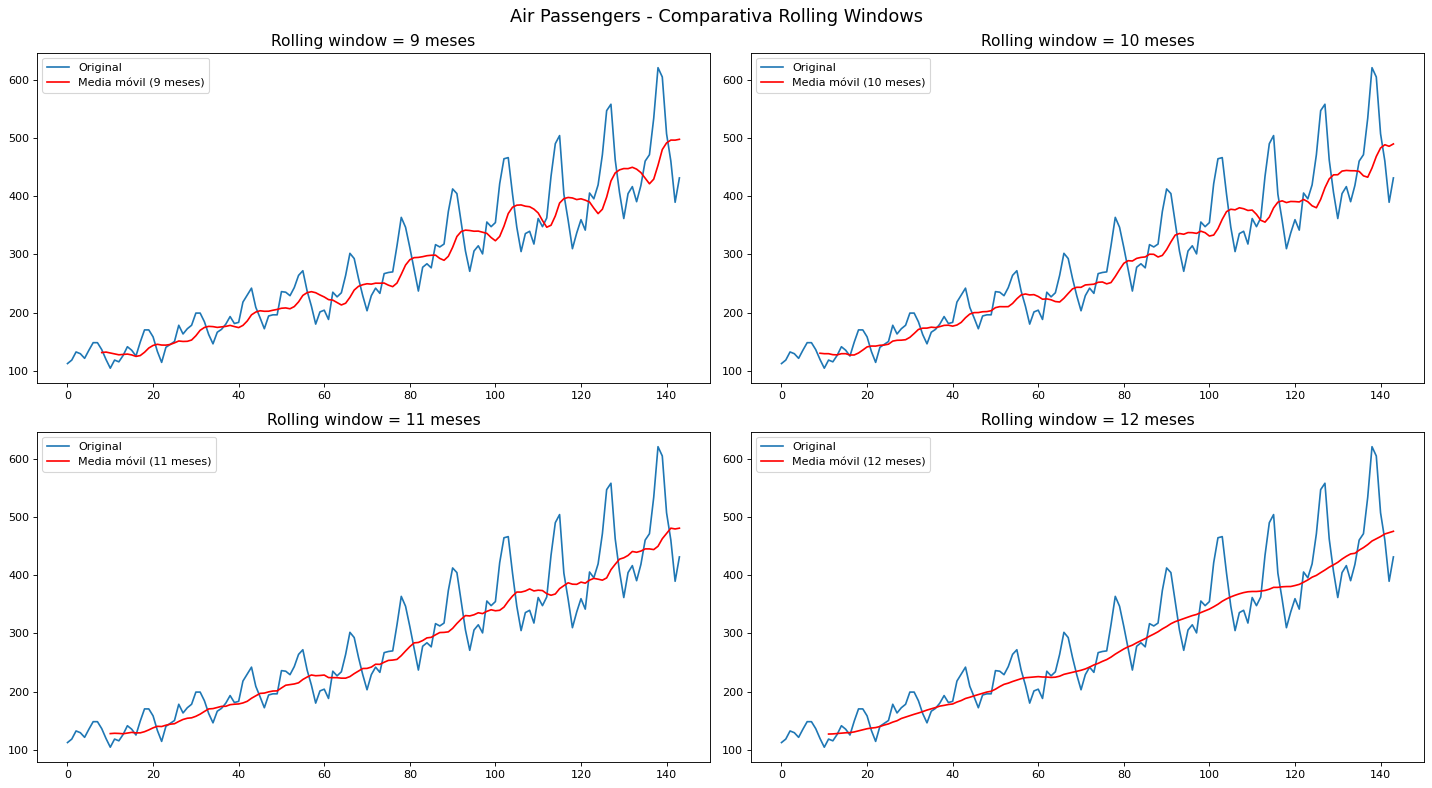

In [132]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10), dpi=80)

windows = [9, 10, 11, 12]

for ax, w in zip(axes.flat, windows):
    rolling_mean = df["value"].rolling(window=w).mean()
    ax.plot(df["value"], label="Original")
    ax.plot(rolling_mean, label=f"Media móvil ({w} meses)", color="red")
    ax.set_title(f"Rolling window = {w} meses", fontsize=14)
    ax.legend()

plt.suptitle("Air Passengers - Comparativa Rolling Windows", fontsize=16)
plt.tight_layout()
plt.show();

La media móvil de 9 es la más marcada.

## 3. Comprueba de manera estadística si la serie es o no estacionaria.

In [133]:
from statsmodels.tsa.stattools import adfuller

stat, pval, usedlag, nobs,crtivals, icbest = adfuller(df["value"].values) 
print(pval)

# Dickey-Fuller 0.99: no es serie estacionaria

0.991880243437641


## 4. Aplica una transformación logarítmica sobre los datos para mejorar el proceso de transformación de tu time series a stationary.
Acuérdate después del forecast de invertir la transformación

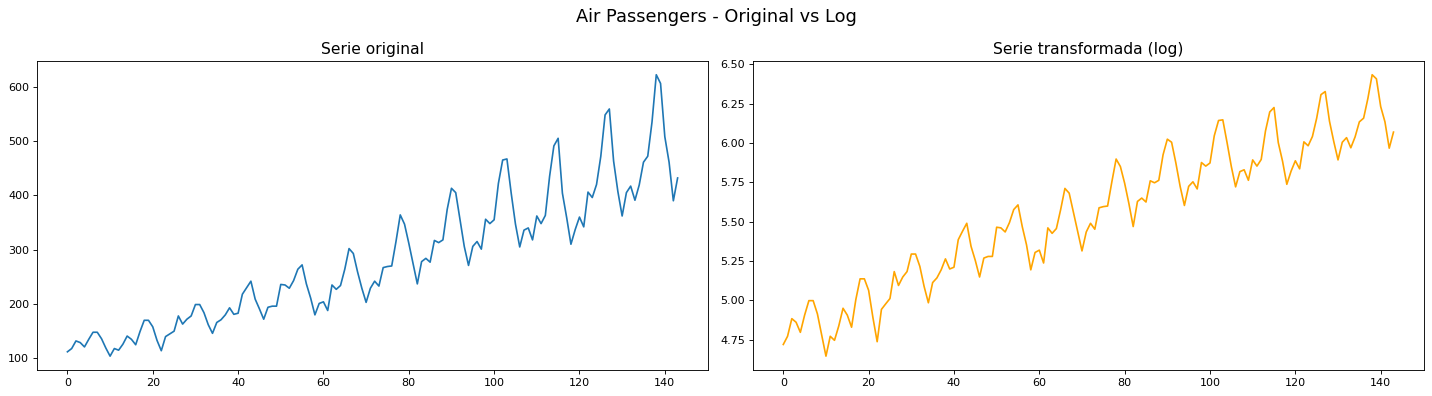

In [134]:
# Transformación logarítmica
df["value_log"] = np.log(df["value"])

# Visualizar original vs log
fig, axes = plt.subplots(1, 2, figsize=(18, 5), dpi=80)

axes[0].plot(df["value"])
axes[0].set_title("Serie original", fontsize=14)

axes[1].plot(df["value_log"], color="orange")
axes[1].set_title("Serie transformada (log)", fontsize=14)

plt.suptitle("Air Passengers - Original vs Log", fontsize=16)
plt.tight_layout()
plt.show();

## 5. Divide en train y test. Guarda 20 muestras para test.

In [135]:
# SIN TRANSFORMACIÓN LOGARÍTMICA

values = df.values
N = 144
Tp = 124 # tengo 144 - 20 para test = 124 para train   

train, test = values[0:Tp ,:], values[Tp:N,:]

print("Tamaño train:", train.shape)
print("Tamaño test:", test.shape)

Tamaño train: (124, 5)
Tamaño test: (20, 5)


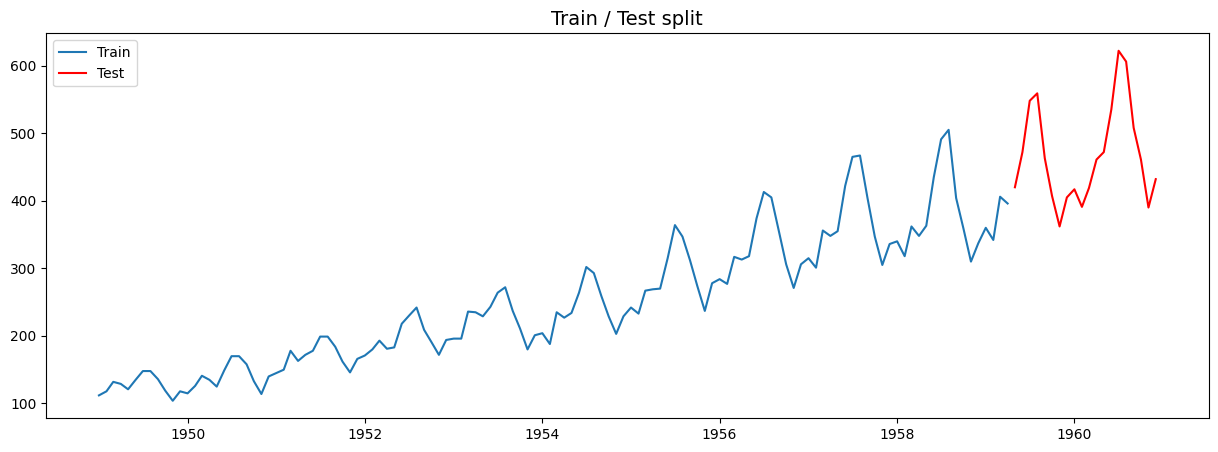

In [136]:
import matplotlib.pyplot as plt

fechas = pd.to_datetime(df["date"])  # recuperamos las fechas de la columna date

plt.figure(figsize=(15, 5))
plt.plot(fechas[:Tp], train[:, 1], label="Train")
plt.plot(fechas[Tp:], test[:, 1], color='r', label="Test")
plt.title("Train / Test split", fontsize=14)
plt.legend()
plt.show();

In [137]:
# CON TRANSFORMACIÓN LOGARÍTMICA

value_log = df.value_log
N = 144
Tp = 124 # tengo 144 - 20 para test = 124 para train   

train_log = value_log.iloc[0:Tp]
test_log = value_log.iloc[Tp:N]

print("Tamaño train:", train_log.shape)
print("Tamaño test:", test_log.shape)

Tamaño train: (124,)
Tamaño test: (20,)


## 6. Crea tu primer modelo ARIMA
Habrá varias combinaciones en función de sus hiperparámetros... Mide el MAE y RMSE del modelo en predicción. Ten en cuenta el parámetro "m" de la función ARIMA, mediante el cual se establece el seasonality.

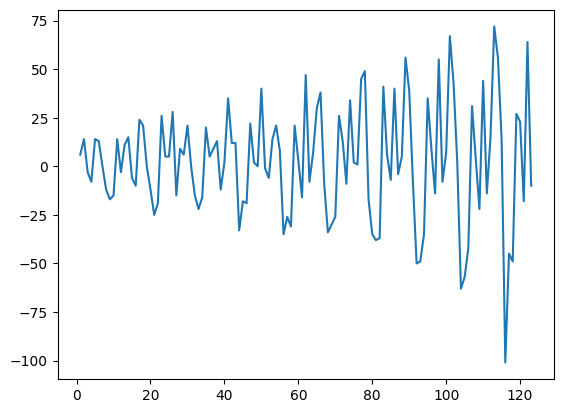

In [138]:
# SIN TRANSFORMACIÓN LOGARÍTMICA

# d = RESTAR CADA VALOR POR EL ANTERIOR --> TENDENCIA
d = 1

diff = pd.Series(train[:, 1])  # columna 1 = value
for _ in range(d):
    diff = diff.diff()
plt.plot(diff)
plt.show();

In [139]:
from pmdarima.arima import auto_arima

smodel = auto_arima(train[:, 1], # AQUÍ HAY QUE DARLE TRAIN (en mi caso, la COLUMNA específica)
                    test='adf',
                    start_p=1,
                    start_q=1,
                    max_p=5,
                    max_q=5,
                    d=None, # d para TENDENCIA --> restar cada valor por el anterior, con NONE le decimos que elija a ARIMA mediante ADF
                    m=9, # Periodo estacional
                    seasonal=True,
                    start_P=0,
                    D=1, # d para la parte estacional --> diferencia UNA VEZ estacionalmente
                    trace=True,
                    error_action='ignore',  
                    suppress_warnings=True, 
                    stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[9] intercept   : AIC=inf, Time=0.38 sec
 ARIMA(0,0,0)(0,1,0)[9] intercept   : AIC=1256.397, Time=0.00 sec
 ARIMA(1,0,0)(1,1,0)[9] intercept   : AIC=1148.335, Time=0.16 sec
 ARIMA(0,0,1)(0,1,1)[9] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(0,0,0)(0,1,0)[9]             : AIC=1267.508, Time=0.01 sec
 ARIMA(1,0,0)(0,1,0)[9] intercept   : AIC=1180.817, Time=0.02 sec
 ARIMA(1,0,0)(2,1,0)[9] intercept   : AIC=1140.024, Time=0.38 sec
 ARIMA(1,0,0)(2,1,1)[9] intercept   : AIC=inf, Time=0.44 sec
 ARIMA(1,0,0)(1,1,1)[9] intercept   : AIC=inf, Time=0.39 sec
 ARIMA(0,0,0)(2,1,0)[9] intercept   : AIC=1221.603, Time=0.27 sec
 ARIMA(2,0,0)(2,1,0)[9] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(1,0,1)(2,1,0)[9] intercept   : AIC=1108.977, Time=0.41 sec
 ARIMA(1,0,1)(1,1,0)[9] intercept   : AIC=1128.101, Time=0.22 sec
 ARIMA(1,0,1)(2,1,1)[9] intercept   : AIC=inf, Time=0.59 sec
 ARIMA(1,0,1)(1,1,1)[9] intercept   : AIC=inf, Time=0.49 sec
 A

In [140]:
smodel
smodel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  124
Model:             SARIMAX(5, 0, 2)x(2, 1, [], 9)   Log Likelihood                -484.348
Date:                           sá., 09 may. 2026   AIC                            990.697
Time:                                    11:34:37   BIC                           1020.891
Sample:                                         0   HQIC                          1002.952
                                            - 124                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     17.7220      4.943      3.585      0.000       8.034      27.410
ar.L1          1.6647      0.097     17.090      0.000       1.474       1.856
ar.L2         -1.7253      0.209     -8.248      0.000      -2.135      -1.315
ar.L3          0.7568      0.278      2.721      0.006       0.212       1.302
ar.L4         -0.0819      0.222     -0.368      0.713      -0.517       0.354
ar.L5          0.0075      0.114      0.065      0.948      -0.217       0.231
ma.L1         -0.6618      0.046    -14.298      0.000      -0.753      -0.571
ma.L2          0.9674      0.052     18.582      0.000       0.865       1.069
ar.S.L9       -0.1447      0.063     -2.300      0.021      -0.268      -0.021
ar.S.L18      -0.8726      0.057    -15.181      0.000      -0.985      -0.760
sigma2       201.4301     38.416      5.243      0.000     126.135     276.725
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):                 2.39
Prob(Q):                              0.70   Prob(JB):                         0.30
Heteroskedasticity (H):               3.23   Skew:                             0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [141]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

predictions = smodel.predict(len(test))

mae = mean_absolute_error(test[:, 1], predictions)
rmse = np.sqrt(mean_squared_error(test[:, 1], predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 30.021133906990805
RMSE: 39.54236296596552


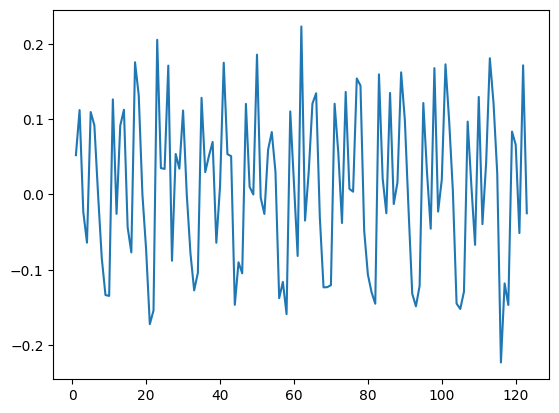

In [142]:
# CON TRANSFORMACIÓN LOGARÍTMICA

# d = RESTAR CADA VALOR POR EL ANTERIOR --> TENDENCIA
d = 1

diff = pd.Series(train_log)
for _ in range(d):
    diff = diff.diff()
plt.plot(diff)
plt.show();

In [143]:
from pmdarima.arima import auto_arima

smodel_log = auto_arima(train_log,
                    test='adf',
                    start_p=1,
                    start_q=1,
                    max_p=5,
                    max_q=5,
                    d=None, # d para TENDENCIA --> restar cada valor por el anterior, con NONE le decimos que elija a ARIMA mediante ADF
                    m=9, # Periodo estacional
                    seasonal=True,
                    start_P=0,
                    D=1, # d para la parte estacional --> diferencia UNA VEZ estacionalmente
                    trace=True,
                    error_action='ignore',  
                    suppress_warnings=True, 
                    stepwise=True)

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[9] intercept   : AIC=inf, Time=0.50 sec
 ARIMA(0,0,0)(0,1,0)[9] intercept   : AIC=-41.867, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[9] intercept   : AIC=-148.508, Time=0.24 sec
 ARIMA(0,0,1)(0,1,1)[9] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(0,0,0)(0,1,0)[9]             : AIC=-25.326, Time=0.01 sec
 ARIMA(1,0,0)(0,1,0)[9] intercept   : AIC=-114.398, Time=0.04 sec
 ARIMA(1,0,0)(2,1,0)[9] intercept   : AIC=-157.473, Time=0.42 sec
 ARIMA(1,0,0)(2,1,1)[9] intercept   : AIC=inf, Time=0.88 sec
 ARIMA(1,0,0)(1,1,1)[9] intercept   : AIC=inf, Time=0.63 sec
 ARIMA(0,0,0)(2,1,0)[9] intercept   : AIC=-76.374, Time=0.19 sec
 ARIMA(2,0,0)(2,1,0)[9] intercept   : AIC=-224.727, Time=0.87 sec
 ARIMA(2,0,0)(1,1,0)[9] intercept   : AIC=-176.764, Time=0.23 sec
 ARIMA(2,0,0)(2,1,1)[9] intercept   : AIC=-249.305, Time=0.79 sec
 ARIMA(2,0,0)(1,1,1)[9] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(2,0,0)(2,1,2)[9] intercept   : AIC=-248.968, Time=1.10

In [144]:
smodel_log
smodel_log.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  124
Model:             SARIMAX(5, 0, 1)x(2, 1, 1, 9)   Log Likelihood                 160.409
Date:                          sá., 09 may. 2026   AIC                           -298.818
Time:                                   11:35:17   BIC                           -268.624
Sample:                                        0   HQIC                          -286.563
                                           - 124                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0407      0.029      1.423      0.155      -0.015       0.097
ar.L1          0.5788      0.186      3.119      0.002       0.215       0.942
ar.L2         -0.0292      0.193     -0.151      0.880      -0.408       0.350
ar.L3         -0.2842      0.134     -2.127      0.033      -0.546      -0.022
ar.L4         -0.0973      0.123     -0.793      0.428      -0.338       0.143
ar.L5          0.6076      0.101      6.012      0.000       0.410       0.806
ma.L1          0.2314      0.213      1.085      0.278      -0.187       0.649
ar.S.L9       -0.0577      0.059     -0.976      0.329      -0.173       0.058
ar.S.L18      -0.8880      0.043    -20.733      0.000      -0.972      -0.804
ma.S.L9       -0.7024      0.131     -5.346      0.000      -0.960      -0.445
sigma2         0.0024      0.000      5.513      0.000       0.002       0.003
===================================================================================
Ljung-Box (L1) (Q):                   1.32   Jarque-Bera (JB):                 5.09
Prob(Q):                              0.25   Prob(JB):                         0.08
Heteroskedasticity (H):               0.69   Skew:                             0.50
Prob(H) (two-sided):                  0.26   Kurtosis:                         2.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [145]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

predictions_log = smodel_log.predict(len(test_log))

mae = mean_absolute_error(test_log, predictions)
rmse = np.sqrt(mean_squared_error(test_log, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 444.8296569579482
RMSE: 446.7373538140926


## 7. Representa en una gráfica los datos de test y tus predicciones.

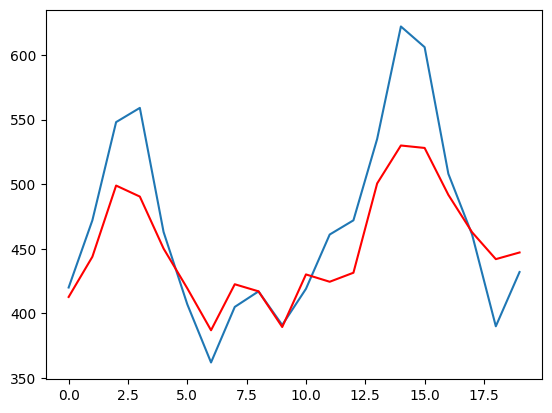

In [146]:
# SIN TRANSFORMACIÓN LOGARÍTMICA

plt.plot(test[:, 1])
plt.plot(predictions,color='red'); # predicción en rojo

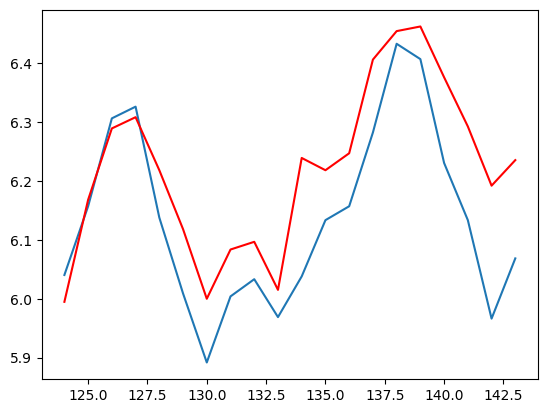

In [147]:
# CON TRANSFORMACIÓN LOGARÍTMICA

plt.plot(test_log)
plt.plot(predictions_log,color='red'); # predicción en rojo

La logarítmica entiende mejor la estacionalidad y la tendencia.

## 8. Prueba otros modelos supervisados, a ver qué performance presentan.

In [153]:
df2 = df.copy()
emb_size = 9 # Pasos

for i in range(1, emb_size+1):
    df2['lag' + str(i)] = df2['value'].shift(i) # lo hago con el normal, sin transformación logarítmica
    
df2.dropna(inplace=True)
df2.set_index("date", inplace=True)
df2.drop(["year", "month", "value_log"], axis=1, inplace=True)
df2.reset_index(drop=True, inplace=True)
df2

,value,lag1,lag2,lag3,lag4,lag5,lag6,lag7,lag8,lag9
0,119,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0,112.0
1,104,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0
2,118,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0
3,115,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0
4,126,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0
...,...,...,...,...,...,...,...,...,...,...
130,606,622.0,535.0,472.0,461.0,419.0,391.0,417.0,405.0,362.0
131,508,606.0,622.0,535.0,472.0,461.0,419.0,391.0,417.0,405.0
132,461,508.0,606.0,622.0,535.0,472.0,461.0,419.0,391.0,417.0
133,390,461.0,508.0,606.0,622.0,535.0,472.0,461.0,419.0,391.0


In [165]:
values = df2.values

#Volvemos a montar xtrain, xtest... NO ENTIENDO ESTO
trainX = values[0:Tp-emb_size, 1:].reshape(-1, 1, emb_size)
trainY = values[0:Tp-emb_size, 0]
testX = values[Tp-emb_size:N-emb_size, 1:].reshape(-1, 1, emb_size)
testY = values[Tp-emb_size:N-emb_size, 0]

print("Tamaño datos Train:", trainX.shape)
print("Target en Train:", trainY.shape)
print("Tamaño datos test:", testX.shape)
print("Target en Test:", testY.shape)

Tamaño datos Train: (115, 1, 9)
Target en Train: (115,)
Tamaño datos test: (20, 1, 9)
Target en Test: (20,)


In [166]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam, RMSprop

def rnn_simple(num_units=128, embedding=9, num_dense=32, lr=0.001): # embedding 9 es el paso/lag de 9
    """
    Construye un modelo sencillo usando capas LSTM

    Arguments:
              num_units: Número de unidades en la capa LSTM
              embedding: Tamaño del embedding (pasos)
              num_dense: Número de neuronas en la capa densa
              lr: Learning rate (RMSprop optimizer)
    Returns:
              Un modelo Keras (arquitectura LSTM -> Densa -> Densa(1))
    """
    model = Sequential()
    # Long short term memory
    # Esto es capa de entrada + capa con 128 neuronas con su función de activacion
    model.add(LSTM(units=num_units, input_shape=(1,embedding), activation="relu")) # aquí metemos LSTM
    model.add(Dense(num_dense, activation="relu"))
    model.add(Dense(1)) # salida una sola neurona, sin activación
    model.compile(loss='mean_squared_error',
                  optimizer=RMSprop(lr), # adam
                  metrics=['mae'])
    
    return model

In [167]:
model = rnn_simple() # Taking the defaults
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 128)            │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,817 (292.25 KB)

 Trainable params: 74,817 (292.25 KB)

 Non-trainable params: 0 (0.00 B)

In [168]:
from tensorflow.keras.callbacks import Callback

class MyCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch+1) % 50 == 0 and epoch>0:
            print("Epoch number {} done".format(epoch+1))

In [169]:
batch_size=16
num_epochs = 1000


model.fit(trainX,trainY, 
          epochs=num_epochs, 
          batch_size=batch_size, 
          callbacks=[MyCallback()],verbose=0)

Epoch number 50 done
Epoch number 100 done
Epoch number 150 done
Epoch number 200 done
Epoch number 250 done
Epoch number 300 done
Epoch number 350 done
Epoch number 400 done
Epoch number 450 done
Epoch number 500 done
Epoch number 550 done
Epoch number 600 done
Epoch number 650 done
Epoch number 700 done
Epoch number 750 done
Epoch number 800 done
Epoch number 850 done
Epoch number 900 done
Epoch number 950 done
Epoch number 1000 done


In [170]:
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)
predicted = np.concatenate((trainPredict,testPredict),axis=0)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


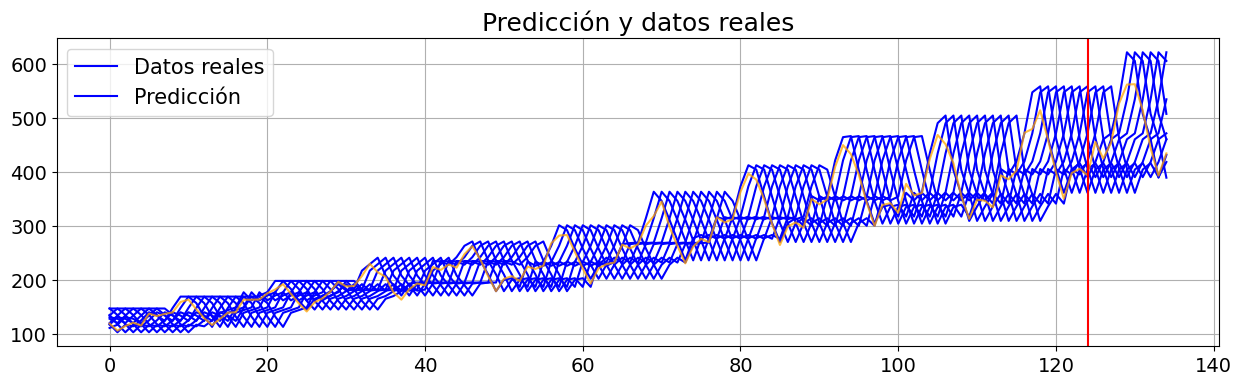

In [172]:
index = df2.index.values
plt.figure(figsize=(15,4))
plt.title("Predicción y datos reales",fontsize=18)
plt.plot(index,df2,c='blue')
plt.plot(index,predicted,c='orange',alpha=0.75)
plt.legend(['Datos reales','Predicción'],fontsize=15)
plt.axvline(df.index[Tp], c="r")
plt.grid(True)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show();

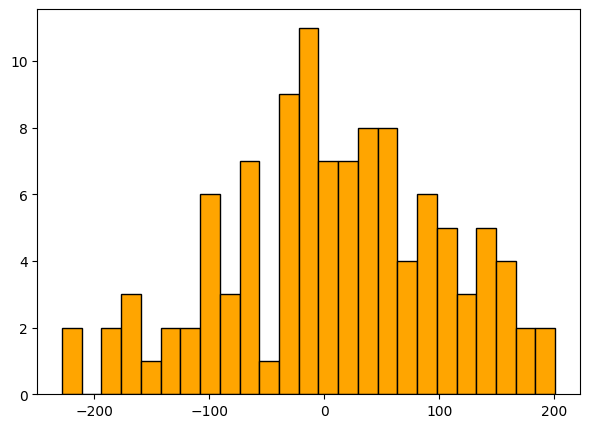

In [ ]:
error = predicted[Tp:N]-df2[Tp:N]
# Ravel elimina una dimension, lo aplana todo. Como flatten
error = np.array(error).ravel()

plt.figure(figsize=(7,5))
plt.hist(error,bins=25,edgecolor='k',color='orange')
plt.show();

# distribución de errores: no está mal